* [#59](https://github.com/salgo60/spa2Commons/issues/59)
  * dHash [#64](https://github.com/salgo60/spa2Commons/issues/64)
* [59_SPA_dubbletter_1](https://github.com/salgo60/spa2Commons/blob/main/Notebook/59_SPA_dubbletter_1.ipynb)

SPA dubbletter

In [1]:
from datetime import datetime
start_time  = datetime.now()
print("Last run: ", start_time)

Last run:  2026-03-13 16:46:24.896626


In [2]:
import sys
print(sys.executable)

/Library/Frameworks/Python.framework/Versions/3.12/bin/python3.12


In [3]:
import cv2
print(cv2.__version__)

4.11.0


In [4]:
import numpy
print(numpy.__version__)

1.26.4


In [5]:
import numpy
import scipy

print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)

numpy: 1.26.4
scipy: 1.17.1


In [6]:
from pathlib import Path
from PIL import Image
import numpy as np

image_dir = Path("SPAtestpictures")

def dhash(image, hash_size=8):
    
    image = image.convert("L").resize((hash_size + 1, hash_size))
    pixels = np.array(image)

    diff = pixels[:,1:] > pixels[:,:-1]

    return diff.flatten()


hashes = {}

for img_path in sorted(image_dir.glob("*.jpg")):

    try:
        img = Image.open(img_path)
    except:
        continue

    h = dhash(img)

    for name, old_h in hashes.items():

        dist = np.sum(h != old_h)

        if dist <= 5:
            print(f"SIMILAR: {img_path.name} == {name} (distance {dist})")

    hashes[img_path.name] = h

SIMILAR: _P7S9YzQCjAAAAAAAAAvcQ.jpg == 4e1scVvZ-EAAAAAAAAAQKQ.jpg (distance 0)
SIMILAR: ciLMGSqrYjAAAAAAAAAzog.jpg == WQknIBFpuuAAAAAAAAN2aA.jpg (distance 2)
SIMILAR: j6S8rJvx9lAAAAAAAAAcKw.jpg == WQknIBFpuuAAAAAAAAN6yw.jpg (distance 3)
SIMILAR: sj9PGLAlnmUAAAAAABL8Cw.jpg == Dysd0OxEWfAAAAAAAABakQ.jpg (distance 0)
SIMILAR: sj9PGLAlnmUAAAAAABM1WQ.jpg == j6S8rJvx9lAAAAAAAACujA.jpg (distance 0)
SIMILAR: sj9PGLAlnmUAAAAAABODtA.jpg == ciLMGSqrYjAAAAAAAABsEA.jpg (distance 0)
SIMILAR: sj9PGLAlnmUAAAAAABTDCQ.jpg == ciLMGSqrYjAAAAAAAABqUA.jpg (distance 0)
SIMILAR: xnPIH5lXePAAAAAAAAAWjw.jpg == sj9PGLAlnmUAAAAAABKn8Q.jpg (distance 0)


## Skalar detta  
Short answer: No — this will not scale well to 900 000 images. ⚠️

The algorithmic structure is O(N²) because every new image is compared with all previous hashes.

### Problem: Skalning till 900 000 bilder

Den ursprungliga algoritmen jämför varje bildhash med alla tidigare hashvärden.

> for name, old_h in hashes.items():
> 
>    dist = np.sum(h != old_h) 

Detta ger kvadratisk komplexitet (O(N²)). 

### Idé: Bucket-indexering av hashvärden

Istället för att jämföra varje bild med alla tidigare, kan vi gruppera hashvärden i buckets baserat på de första bitarna i hashvärdet.

In [9]:
from collections import defaultdict

buckets = defaultdict(list)

for img_path in image_dir.glob("*.jpg"):

    img = Image.open(img_path)
    h = dhash(img)

    key = tuple(h[:16])   # bucket key

    for name, old_h in buckets[key]:
        dist = np.sum(h != old_h)
        if dist <= 5:
            print(f"SIMILAR: {img_path.name} == {name} (distance {dist})")

    buckets[key].append((img_path.name, h))

SIMILAR: j6S8rJvx9lAAAAAAAAAcKw.jpg == WQknIBFpuuAAAAAAAAN6yw.jpg (distance 3)
SIMILAR: sj9PGLAlnmUAAAAAABTDCQ.jpg == ciLMGSqrYjAAAAAAAABqUA.jpg (distance 0)
SIMILAR: xnPIH5lXePAAAAAAAAAWjw.jpg == sj9PGLAlnmUAAAAAABKn8Q.jpg (distance 0)
SIMILAR: _P7S9YzQCjAAAAAAAAAvcQ.jpg == 4e1scVvZ-EAAAAAAAAAQKQ.jpg (distance 0)
SIMILAR: sj9PGLAlnmUAAAAAABODtA.jpg == ciLMGSqrYjAAAAAAAABsEA.jpg (distance 0)
SIMILAR: sj9PGLAlnmUAAAAAABM1WQ.jpg == j6S8rJvx9lAAAAAAAACujA.jpg (distance 0)
SIMILAR: sj9PGLAlnmUAAAAAABL8Cw.jpg == Dysd0OxEWfAAAAAAAABakQ.jpg (distance 0)


### Resultat 


Detta gör att metoden kan skala till hundratusentals eller miljontals bilder betydligt bättre.

In [10]:
import pandas as pd
from IPython.display import display

data = [
    ["Naiv O(N²)", "~405 miljarder"],
    ["Bucket-index", "~12 miljoner"]
]

df = pd.DataFrame(data, columns=["Metod", "Jämförelser"])

display(df)

,Metod,Jämförelser
0,Naiv O(N²),~405 miljarder
1,Bucket-index,~12 miljoner


In [12]:
import pandas as pd

# antal bilder
N = 893_799

# Naiv metod O(N²)
naive = N * (N - 1) // 2

# Bucket-index antagande
buckets = 2**16
avg_bucket_size = N / buckets

# ungefärliga jämförelser
bucket_comparisons = N * avg_bucket_size

df = pd.DataFrame({
    "Metod": ["Naiv O(N²)", "Bucket-index"],
    "Jämförelser": [naive, int(bucket_comparisons)]
})

df["Jämförelser"] = df["Jämförelser"].map(lambda x: f"{x:,}".replace(",", " "))
df

,Metod,Jämförelser
0,Naiv O(N²),399 437 879 301
1,Bucket-index,12 189 890


In [13]:
pd.DataFrame({
    "Antal bilder": [N],
    "Buckets": [buckets],
    "Genomsnitt bilder per bucket": [round(avg_bucket_size,2)]
})

,Antal bilder,Buckets,Genomsnitt bilder per bucket
0,893799,65536,13.64


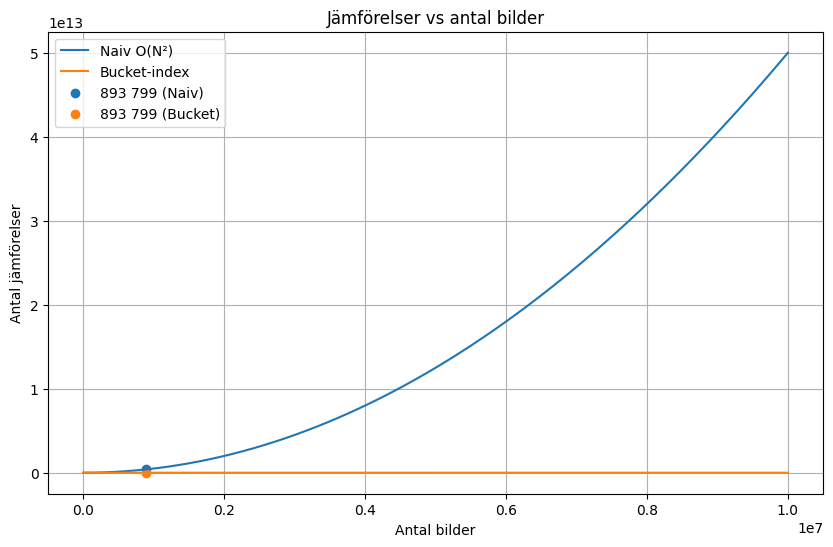

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# intervall upp till 10 miljoner
N = np.linspace(1, 10_000_000, 200)

# beräkningar
naive = N*(N-1)/2

buckets = 2**16
bucket = N*(N/buckets)

# punkt vi vill markera
current = 893_799
naive_current = current*(current-1)/2
bucket_current = current*(current/buckets)

plt.figure(figsize=(10,6))

plt.plot(N, naive, label="Naiv O(N²)")
plt.plot(N, bucket, label="Bucket-index")

plt.scatter([current], [naive_current], label="893 799 (Naiv)")
plt.scatter([current], [bucket_current], label="893 799 (Bucket)")

plt.xlabel("Antal bilder")
plt.ylabel("Antal jämförelser")
plt.title("Jämförelser vs antal bilder")

plt.legend()
plt.grid(True)

plt.show()

In [7]:
from datetime import datetime
end = datetime.now()
print("Ended: ", end) 
print('Time elapsed (hh:mm:ss.ms) {}'.format(datetime.now() - start_time))

Ended:  2026-03-13 16:46:25.461187
Time elapsed (hh:mm:ss.ms) 0:00:00.564605
